In [1]:
import torch
import numpy as np
from scipy.io import loadmat, savemat
from scipy import constants as cts
from tqdm import tqdm
from ipywidgets import interact, widgets
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

disp = loadmat('disp.mat')
res = loadmat('res.mat')
sim = loadmat('sim.mat')

# df = pd.read_csv('./DKS_init.csv')
# df["DKS_init"] = df.DKS_init.apply(lambda val: complex(val.strip('()')))
# δω = df.det.values[0] * 2*np.pi
# DKS_init = df.DKS_init.values



sim['DKS_init'] = np.array([complex(x.strip()) for x in sim['DKS_init']])

# Convert the complex numbers to np.complex64
sim['DKS_init'] = sim['DKS_init'].astype(np.complex128)

tol = 1e-3
max_iter = 10
step_factor = 0.1

c0 = 299792458
h_bar = cts.hbar

In [2]:
# myDKS = loadmat('My_DKS_init_multi2.mat')
# sim['DKS_init'] =  myDKS['DKS_init'][0]

# sim['domega_init'] = myDKS['detuning']
# sim['domega_end'] = myDKS['detuning']

In [3]:
# write a function that converts the dictorionary to a tensor. Drop the first 3 keys
def dict_to_tensor(dic):
    dic.pop('__header__', None)
    dic.pop('__version__', None)
    dic.pop('__globals__', None)
    dic.pop('dispfile', None)

    tensor_dic = dict()
    # convert the dictionary to a tensor
    for key in dic:
        if isinstance(dic[key], np.ndarray):
            if key == 'DKS_init':
                tensor_dic[key] = torch.tensor(dic[key], device=device, dtype=torch.complex64)
            else:
                dic[key] = np.where(dic[key] == 'None', None, dic[key])
                dic[key] = dic[key].astype(np.float64)
                tensor_dic[key] = torch.tensor(dic[key], device=device)
        else:
            tensor_dic[key] = dic[key]
    return tensor_dic

def tensor_to_dict(tensor):
    dic = dict()
    for key in tensor:
        # print(key)
        if isinstance(tensor[key], torch.Tensor):
            if tensor[key].dtype == torch.complex128:
                dic[key] = tensor[key].cpu().numpy().astype(np.complex128)
            else:   
                dic[key] = tensor[key].cpu().numpy().astype(np.float64)
        else:
            dic[key] = tensor[key]
    return dic

disp_tensor = dict_to_tensor(disp)
res_tensor = dict_to_tensor(res)
sim.pop('domega', None)
sim['domega'] = np.array(['None',0])
sim_tensor = dict_to_tensor(sim)

In [4]:
disp_tensor['D1'] = disp_tensor['D1'][0]
disp_tensor['FSR'] = disp_tensor['FSR'][0]
disp_tensor['FSR_center'] = disp_tensor['FSR_center'][0]

for key in res_tensor:
    res_tensor[key] = res_tensor[key][0]

# if ndim>1 then squeeze the tensor
for key in sim_tensor:
    if sim_tensor[key].ndim > 1:
        sim_tensor[key] = sim_tensor[key][0]

In [5]:
ng = disp_tensor['ng']
R = res_tensor['R']
gamma = res_tensor['gamma']
L = 2*torch.pi*R
# print all shapes
# print('ng:', ng.shape)
# print('R:', R.shape)
# print('gamma:', gamma.shape)
# %%
Q0 = res_tensor['Qi']
Qc = res_tensor['Qc']
fpmp = sim_tensor['f_pmp']
Ppmp = sim_tensor['Pin']
# Ppmp = torch.tensor([0.16], dtype=torch.float64)
phi_pmp = sim_tensor['phi_pmp']
num_probe = sim_tensor['num_probe']
# num_probe = num_probe[0].cpu().numpy().astype(int)
num_probe = 5000
fcenter = sim_tensor['f_center']

DKSinit_real = torch.real(sim_tensor['DKS_init'])
if sim_tensor['DKS_init'].dtype == torch.complex128 or sim_tensor['DKS_init'].dtype == torch.complex64:
    DKSinit_imag = torch.imag(sim_tensor['DKS_init'])
else:
    DKSinit_imag = torch.zeros_like(DKSinit_real, device=device)

In [6]:
DKS_init = torch.complex(DKSinit_real, DKSinit_imag)

D1 = disp_tensor['D1']
FSR = D1/(2*torch.pi)
omega0 = 2*torch.pi*fpmp
omega_center = 2*torch.pi*fcenter

tR = 1/FSR
T = 1*tR
kext = (omega0[0]/Qc) * tR
k0 = (omega0[0]/Q0) * tR
alpha = k0+kext

kext = torch.tensor(kext, device=device, dtype=torch.float64) if not isinstance(kext, torch.Tensor) else kext
k0 = torch.tensor(k0, device=device, dtype=torch.float64) if not isinstance(k0, torch.Tensor) else k0
alpha = torch.tensor(alpha, device=device, dtype=torch.float64) if not isinstance(alpha, torch.Tensor) else alpha

del_omega_init = sim_tensor['domega_init']
del_omega_end = sim_tensor['domega_end']
del_omega_stop = sim_tensor['domega_stop']
ind_sweep = sim_tensor['ind_pump_sweep'] 
t_end = sim_tensor['Tscan']
Dint = disp_tensor['Dint_new']#[0]

In [7]:
del_omega = sim['domega']
ind_pmp = [ii for ii in sim_tensor['ind_pmp'].int().cpu().numpy()]    
mu_sim = sim_tensor['mucenter']
mu = torch.arange(mu_sim[0], mu_sim[1]+1, device=device)
# find center of mu
mu0 = torch.where(mu == 0)[0][0].int().cpu().numpy()+1

d_omega = 2*torch.pi*FSR * torch.arange(mu_sim[0], mu_sim[-1]+1, device=device)
domega_pmp1 = 2*torch.pi*FSR * torch.arange(mu_sim[0]-ind_pmp[0]-1, mu_sim[-1]-ind_pmp[0], device=device)
omega1 = omega0[0] + domega_pmp1

Dint = Dint-Dint[mu0-1]

Ptot = 0#torch.zeros(1, device=device)
for ii in range(len(fpmp)):
    Ptot += Ppmp[ii]

dt = 1
t_end = t_end*tR
t_ramp = t_end

In [8]:
Nt = torch.round(t_ramp/tR/dt)[0].int()
theta = torch.linspace(0, 2*torch.pi, len(mu), device=device)
del_omega_tot = torch.abs(del_omega_end)+torch.abs(del_omega_init)
del_omega_perc = -1*torch.sign(del_omega_end+del_omega_init)*(torch.abs(del_omega_end+del_omega_init)/2)/del_omega_tot
# t_sim = torch.linspace(-t_ramp[0]/2 + del_omega_perc[0]*t_ramp[0], t_ramp[0]/2 + del_omega_perc[0]*t_ramp[0], Nt, device=device, dtype=torch.float64)
t_sim = torch.linspace(0, t_ramp[0], Nt, device=device, dtype=torch.float64)

# xx = torch.arange(0,Nt, device=device)
del_omega_all = torch.ones(len(fpmp), Nt, device=device, dtype=torch.float64)
# ind_sweep = ind_sweep.cpu().numpy().int()
if del_omega_init == del_omega_end:
    Nt = 200000
    del_omega_all = del_omega_init*torch.ones(len(fpmp), Nt, device=device, dtype=torch.float64)
else:
    xx = torch.arange(1,Nt+1, device=device)
    for ii in ind_sweep.cpu().numpy().astype(int):
        # del_omega_all[ii,:] = torch.linspace(del_omega_init[0], del_omega_end[0], Nt)
        del_omega_all[ii,:] = del_omega_init + xx/Nt * (del_omega_end - del_omega_init)

In [9]:
# def Noise():
#     Ephoton = torch.tensor(h_bar)*omega1
#     phase = 2*torch.pi*torch.rand(len(mu),1, device=device)
#     array = torch.rand(len(mu),1, device=device)
#     Enoise = array*torch.sqrt(Ephoton/2)*torch.exp(1j*phase)*len(mu)
#     return torch.fft.ifftshift(torch.fft.ifft(Enoise))

@torch.jit.script
def Noise(h_bar: float, omega1: torch.Tensor, mu_len: int, device: torch.device) -> torch.Tensor:
    Ephoton = torch.tensor(h_bar, device=device) * omega1
    phase = 2 * torch.pi * torch.rand(mu_len,  device=device)
    array = torch.rand(mu_len,  device=device)
    Enoise = array * torch.sqrt(Ephoton / 2) * torch.exp(1j * phase) * mu_len
    return torch.fft.ifftshift(torch.fft.ifft(Enoise)).squeeze()

# fpmp = fpmp[0]
Ain = torch.zeros(len(fpmp), len(mu),dtype=torch.complex128, device=device)
Ein = torch.zeros(len(fpmp), len(mu),dtype=torch.complex128, device=device)

for ii in range(len(fpmp)):
    Ein[ii,int(mu0+ind_pmp[ii])] = torch.sqrt(Ppmp[ii])*len(mu)
    Ain[ii] = torch.fft.ifft(torch.fft.fftshift(Ein[ii],dim=0),dim=0)*torch.exp(-1j*phi_pmp[ii])

# u0 = torch.zeros(len(mu) , dtype=torch.complex128, device=device)
u0 = DKS_init

In [10]:
saved_data = dict()

saved_data['u_probe'] = torch.zeros(num_probe, len(u0), dtype=torch.complex128, device=device)
saved_data['driving_force'] = torch.zeros(num_probe, len(u0), dtype=torch.complex128, device=device)
saved_data['detuning'] = torch.zeros(num_probe, device=device)
saved_data['t_sim'] = torch.zeros(num_probe, device=device)
saved_data['kappa_ext'] = kext
saved_data['kappa_0'] = k0
saved_data['alpha'] = alpha

# dint2 = loadmat('dint.mat')['dint'][:,0]
# Dint_shift = torch.Tensor(dint2, device=device, dtype=torch.complex128)
Dint_shift = torch.fft.ifftshift(Dint)
# %%
def Fdrive(it):
    Force = torch.zeros(len(mu), device=device, dtype=torch.complex128)
    for ii in range(len(fpmp)):
        if ii > 0:
            sigma = (2*del_omega_all[ii,it] + Dint[(mu0)+ind_pmp[ii]] - 0.5*del_omega_all[0,it])*t_sim[it]
        else:
            sigma=torch.zeros(1, device=device)
        Force = Force - 1j*Ain[ii]*torch.exp(1j*sigma)
    return Force #+ Noise(h_bar, omega1, int(len(mu)), device)

# def Fdrive_all(t_sim1=None):
#     if t_sim1 is not None:
#         t_sim = t_sim1
#     Force = 0*torch.exp(1j*theta)
#     Force = Force.unsqueeze(1).repeat(Nt,1).T
#     for ii in range(len(fpmp)):
#         if ii > 0:
#             sigma = (2*del_omega_all[ii,:] + Dint[(mu0-1)+ind_pmp[ii]] - 0.5*del_omega_all[0,:])*t_sim
#             print(sigma.shape)
#         else:
#             sigma=torch.zeros(1, device=device)
#             print(Ain[ii].unsqueeze(1).shape,torch.exp(1j*sigma).unsqueeze(0).shape)
#         Force = Force - 1j*Ain[ii].unsqueeze(1)*torch.exp(1j*sigma).unsqueeze(0)
#     return Force #+ Noise()[0]

def SaveStatus_Callback(it, saved_data, u0, param):
    # if it*num_probe/Nt > param['probe']:
    saved_data['u_probe'][param['probe'],:] = u0
    saved_data['detuning'][param['probe']] = del_omega_all[0][it]
    saved_data['t_sim'][param['probe']] = t_sim[it]
    saved_data['driving_force'][param['probe'],:] = Fdrive(it)
    param['probe'] += 1
    return param

def SaveData(saved_data, name=None):
    saved_data_numpy = tensor_to_dict(saved_data)
    if name is None:
        savemat('SSFM_half_data.mat', saved_data_numpy)
    else:
        savemat(name, saved_data_numpy)

In [11]:
tol = 1e-3
max_iter = 10
success = False

L_h_prop = torch.zeros(len(mu), dtype=torch.complex128, device=device)
A_L_h_prop = torch.zeros(len(mu), dtype=torch.complex128, device=device)
NL_h_prop = torch.zeros(len(mu), dtype=torch.complex128, device=device)
A_h_prop = torch.zeros(len(mu), dtype=torch.complex128, device=device)
A_prop = torch.zeros(len(mu), dtype=torch.complex128, device=device)
NL_h_prop_1 = torch.zeros(len(mu), dtype=torch.complex128, device=device)
NL_prop = torch.zeros(len(mu), dtype=torch.complex128, device=device)
Force = torch.zeros(len(mu), dtype=torch.complex128, device=device)

In [12]:
# # ===== RAMAN PARAMETERS =====
# f_R = 0.027  # Raman fraction for SiN
# tau_R = 100e-9  # Raman time constant

# # Precompute Raman response function
# N_raman = len(mu)
# t_R = np.arange(0, N_raman * tR.cpu().numpy(), tR.cpu().numpy())
# h_R = np.exp(-t_R / tau_R) / tau_R
# h_R = h_R / np.sum(h_R)

# h_R = torch.tensor(h_R, dtype=torch.complex128)
# H_R_FFT = torch.fft.fft(h_R, n=N_raman*2)

# @torch.jit.script
# def raman_response(A: torch.Tensor, H_R_FFT: torch.Tensor) -> torch.Tensor:
#     """Compute Raman convolution: R(t) = ∫ h_R(τ) |A(t-τ)|² dτ"""
#     N = len(A)
#     intensity = torch.abs(A) ** 2
#     intensity_padded = torch.cat([intensity, torch.zeros(N, dtype=intensity.dtype, device=A.device)])
#     INT_FFT = torch.fft.fft(intensity_padded)
#     raman_conv_padded = torch.fft.ifft(H_R_FFT * INT_FFT).real
#     return raman_conv_padded[:N]

In [13]:
# ===== RAMAN PARAMETERS + RESPONSE (drop-in replacement) =====
# ...existing code...

# Raman parameters (SiN example)
f_R = 0.15          # Raman fraction
tau1 = 15e-15        # s
tau2 = 120e-15       # s

# Precompute Raman response on the FAST-time grid (one roundtrip, N samples)
N_raman = int(len(mu))

# tR is your roundtrip time; make it a scalar tensor
tR_scalar = tR if tR.ndim == 0 else tR[0]
dt_fast = (tR_scalar.to(torch.float64) / float(N_raman))  # seconds/sample

t_fast = torch.arange(N_raman, device=device, dtype=torch.float64) * dt_fast

# h_R(t) = [(τ1²+τ2²)/(τ1·τ2²)] exp(-t/τ2) sin(t/τ1), causal (t>=0)
factor = (tau1**2 + tau2**2) / (tau1 * tau2**2)
h_R = factor * torch.exp(-t_fast / tau2) * torch.sin(t_fast / tau1)

# Normalize so integral h_R(t) dt = 1  (discrete: sum(h_R)*dt_fast)
integral = torch.sum(h_R) * dt_fast
h_R = torch.where(integral > 0, h_R / integral, h_R)

# For FFT-based circular convolution on a ring:
# - multiply by dt_fast to approximate the continuous-time integral
# - ifftshift to FFT ordering
# h_R_fft = torch.fft.ifftshift(h_R * dt_fast).to(torch.complex128)
h_R_fft = (h_R * dt_fast).to(torch.complex128)

# N-point FFT => circular convolution (recommended for ring resonators)
H_R_FFT = torch.fft.fft(h_R_fft)  # complex128, length N_raman, on device

@torch.jit.script
def raman_response(A: torch.Tensor, H_R_FFT: torch.Tensor) -> torch.Tensor:
    """
    Raman convolution on a periodic grid (circular):
      R(t) = ∫ h_R(τ) |A(t-τ)|^2 dτ
    Returns R(t) (real-valued).
    """
    power = torch.abs(A) ** 2                       # real
    return torch.fft.ifft(torch.fft.fft(power) * H_R_FFT).real

@torch.jit.script
def NL_with_Raman(
    uu: torch.Tensor,
    gamma: torch.Tensor,
    L: torch.Tensor,
    f_R: float,
    H_R_FFT: torch.Tensor
) -> torch.Tensor:
    """
    Nonlinear operator:
      -i*gamma*L * [ (1-f_R)|u|^2 + f_R*(h_R ⊛ |u|^2) ]
    """
    kerr = torch.abs(uu) ** 2
    if f_R > 0.0:
        raman = raman_response(uu, H_R_FFT)
        total = (1.0 - f_R) * kerr + f_R * raman
    else:
        total = kerr
    return -1j * (gamma * L * total)

In [14]:
# =================================== Raman Check ===========================
# No filepath (drop into a new cell)

# 1) kernel normalization
print("sum(h_R*dt_fast) =", (h_R * dt_fast).sum().item())

# 2) DC invariance
N = N_raman
const_power = torch.ones(N, device=device, dtype=torch.float64) * 3.21
dc_out = torch.fft.ifft(torch.fft.fft(const_power) * H_R_FFT).real
print("DC error (max abs):", (dc_out - const_power).abs().max().item())

sum(h_R*dt_fast) = 1.0
DC error (max abs): 3.552713678800501e-15


In [15]:
@torch.jit.script
def FFT_Lin(it: int, alpha: torch.Tensor, Dint_shift: torch.Tensor, del_omega_all: torch.Tensor, tR: torch.Tensor) -> torch.Tensor:
    '''
    Linear operator
    Input:
        it (int) : Time index
        alpha (torch.Tensor) : Linewidth enhancement factor
        Dint_shift (torch.Tensor) : Dispersive operator
        del_omega_all (torch.Tensor) : Detuning
        tR (torch.Tensor) : Round trip time
    Output:
        torch.Tensor : Linear operator
    '''
    return (-alpha / 2) + 1j * (Dint_shift - del_omega_all[0, it] ) * tR


# Function for the Nonlinear operator
@torch.jit.script
def NL(uu: torch.Tensor, gamma: torch.Tensor, L: torch.Tensor) -> torch.Tensor:
    '''
    Nonlinear operator
    Input:
        uu (torch.Tensor) : Input field
        gamma (torch.Tensor) : Nonlinear coefficient
        L (torch.Tensor) : Length of the resonator
    Output:
        torch.Tensor : Nonlinear operator
    '''
    return -1j * (gamma * L * torch.square(torch.abs(uu)) )

# @torch.jit.script
# def NL_with_Raman(uu: torch.Tensor, gamma: torch.Tensor, L: torch.Tensor, 
#                   f_R: float, raman_resp: torch.Tensor) -> torch.Tensor:
#     """Nonlinear: -iγL[(1-f_R)|A|² + f_R·R(t)]"""
#     kerr_only = (1 - f_R) * torch.square(torch.abs(uu))
#     raman_term = f_R * raman_resp
#     return -1j * (gamma * L * (kerr_only + raman_term))

In [16]:
@torch.jit.script
def ssfm_step(A0: torch.Tensor, it: int, alpha: torch.Tensor, Dint_shift: torch.Tensor,
              del_omega_all: torch.Tensor, tR: torch.Tensor, gamma: torch.Tensor, L: torch.Tensor, 
              max_iter: int, tol: float, dt: int, kext: torch.Tensor, Fdrive_val: torch.Tensor, 
              A_prop: torch.Tensor) -> torch.Tensor:
    
    A0 = A0 + Fdrive_val * torch.sqrt(kext) * dt
    L_h_prop = torch.exp(FFT_Lin(it, alpha, Dint_shift, del_omega_all, tR) * dt / 2)
    A_L_h_prop = torch.fft.ifft(torch.fft.fft(A0) * L_h_prop)
    NL_h_prop_0 = NL(A0, gamma, L)
    A_h_prop = A0
    A_prop = 0*A0.clone()

    for _ in range(max_iter):
        NL_h_prop_1 = NL(A_h_prop, gamma, L)
        NL_prop = (NL_h_prop_0 + NL_h_prop_1) * dt / 2
        A_prop = torch.fft.ifft(torch.fft.fft(A_L_h_prop * torch.exp(NL_prop)) * L_h_prop)
        err = torch.linalg.vector_norm(A_prop - A_h_prop, ord=2, dim=0) / torch.linalg.vector_norm(A_h_prop, ord=2, dim=0)
        if err < tol:
            return A_prop
        A_h_prop = A_prop
    err = torch.linalg.vector_norm(A_prop - A_h_prop, ord=2, dim=0) / torch.linalg.vector_norm(A_h_prop, ord=2, dim=0)
    raise RuntimeError(f"Convergence Error: {err}")



def MainSolver(Nt, saved_data, u0, name=None):
    param = dict()
    param['tol'] = 1e-3
    param['max_iter'] = max_iter
    param['step_factor'] = 0.1
    param['probe'] = 0

    for it in tqdm(range(Nt), ncols=120):
        Fdrive_val = Fdrive(it)
        u0 = ssfm_step(u0, it, alpha, Dint_shift, del_omega_all, tR, gamma, L, 
                       max_iter, tol, dt, kext, Fdrive_val, A_prop)
        if it*num_probe/Nt > param['probe']:
            param = SaveStatus_Callback(it, saved_data, u0, param)
    SaveData(saved_data, name)

In [17]:
# @torch.jit.script
# def ssfm_step(
#     A0: torch.Tensor,
#     it: int,
#     alpha: torch.Tensor,
#     Dint_shift: torch.Tensor,
#     del_omega_all: torch.Tensor,
#     tR: torch.Tensor,
#     gamma: torch.Tensor,
#     L: torch.Tensor,
#     max_iter: int,
#     tol: float,
#     dt: int,
#     kext: torch.Tensor,
#     Fdrive_val: torch.Tensor,
#     A_prop: torch.Tensor,        # (kept to match your current call signature)
#     H_R_FFT: torch.Tensor,       # Raman kernel FFT (N-point, circular)
#     f_R: float                   # Raman fraction
# ) -> torch.Tensor:

#     # drive (your existing model)
#     A0 = A0 + Fdrive_val * torch.sqrt(kext) * dt

#     # linear half-step
#     L_h_prop = torch.exp(FFT_Lin(it, alpha, Dint_shift, del_omega_all, tR) * dt / 2)
#     A_L_h_prop = torch.fft.ifft(torch.fft.fft(A0) * L_h_prop)

#     # --- Nonlinear operator at the beginning (NOW includes Raman) ---
#     NL_h_prop_0 = NL_with_Raman(A0, gamma, L, f_R, H_R_FFT)

#     A_h_prop = A0
#     A_prop = 0 * A0.clone()

#     for _ in range(max_iter):
#         # --- Nonlinear operator at the updated field (NOW includes Raman) ---
#         NL_h_prop_1 = NL_with_Raman(A_h_prop, gamma, L, f_R, H_R_FFT)

#         NL_prop = (NL_h_prop_0 + NL_h_prop_1) * dt / 2

#         # full step: (D/2) -> N -> (D/2)
#         A_prop = torch.fft.ifft(
#             torch.fft.fft(A_L_h_prop * torch.exp(NL_prop)) * L_h_prop
#         )

#         err = torch.linalg.vector_norm(A_prop - A_h_prop, ord=2, dim=0) / torch.linalg.vector_norm(A_h_prop, ord=2, dim=0)
#         if err < tol:
#             return A_prop
#         A_h_prop = A_prop

#     err = torch.linalg.vector_norm(A_prop - A_h_prop, ord=2, dim=0) / torch.linalg.vector_norm(A_h_prop, ord=2, dim=0)
#     raise RuntimeError(f"Convergence Error: {err}")

# def MainSolver(Nt, saved_data, u0, name=None):
#     param = dict()
#     param['tol'] = 1e-3
#     param['max_iter'] = max_iter
#     param['step_factor'] = 0.1
#     param['probe'] = 0

#     for it in tqdm(range(Nt), ncols=120):
#         Fdrive_val = Fdrive(it)
#         u0 = ssfm_step(u0, it, alpha, Dint_shift, del_omega_all, tR, gamma, L, 
#                        max_iter, tol, dt, kext, Fdrive_val, A_prop, H_R_FFT, f_R)
#         if it*num_probe/Nt > param['probe']:
#             param = SaveStatus_Callback(it, saved_data, u0, param)
#     SaveData(saved_data, name)

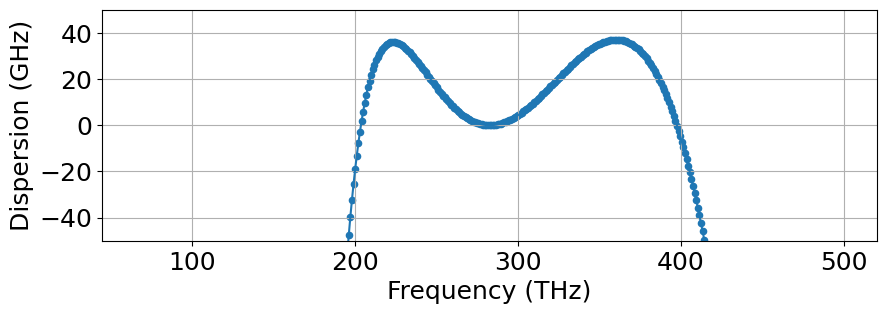

In [18]:
def plot_with_arrows(freq, disp, x_values):
    """
    Plots integrated dispersion with arrows pointing to specified x-values.
    
    Parameters:
    - freq: 1D array of frequency values (x-axis).
    - disp: 2D array of dispersion values (y-axis), shape (n_curves, n_points).
    - x_values: List of x-values to highlight with arrows.
    """
    plt.figure(figsize=(10, 3))
    dint = disp['Dint_sim'] * 1e-9 / (2 * np.pi)
    
    # Plot the dispersion curves
    for idx, dint_ in enumerate(dint):
        plt.plot(freq * 1e-12, dint_, label=f'Dint_pmp_{idx}')
        plt.scatter(freq * 1e-12, dint_, s=20)
        break  # Assuming only one curve for now, remove `break` for multiple curves

    # Plot the arrows for specified x_values
    # for x_val in x_values:
    #     # Find the closest x in the frequency array
    #     closest_idx = np.argmin(np.abs(freq * 1e-12 - x_val))
    #     closest_x = freq[closest_idx] * 1e-12
    #     closest_y = dint_[closest_idx]

    #     # Plot an arrow pointing to the closest point
    #     plt.annotate(
    #         f"{closest_x:.2f} THz",
    #         xy=(closest_x, closest_y),
    #         xytext=(closest_x + 10, closest_y + 10),  # Adjust for arrow placement
    #         arrowprops=dict(facecolor='black', arrowstyle="->"),
    #         fontsize=10,
    #     )
    
    # Add plot details
    plt.ylim(-50, 50)
    # plt.xlim()
    plt.xlabel('Frequency (THz)', fontsize=18)
    plt.ylabel('Dispersion (GHz)', fontsize=18)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid()
    # plt.legend()
    plt.show()

x_val = [283]
freq = (fpmp + np.arange(-220,221)*FSR.item())
plot_with_arrows(freq, disp, x_val)

In [19]:
fpmp.item()

282645887847461.94

In [19]:
name = 'SSFM_half_datav2.mat'
MainSolver(Nt, saved_data, u0,name)

100%|█████████████████████████████████████████████████████████████████████████| 700000/700000 [06:51<00:00, 1701.04it/s]


In [21]:
import matplotlib.pyplot as plt
from scipy.io import loadmat
import numpy as np
name = 'SSFM_half_datav2.mat'
data = loadmat(name)
u_probe = data['u_probe']

# plt.figure(figsize=(10,3))
# plt.imshow(np.abs(u_probe).T, aspect='auto',cmap='jet')
# plt.colorbar()
# plt.show()

driving_force = data['driving_force']
detuning = data['detuning'].T
kext = data['kappa_ext']
alpha = data['alpha']
k0 = data['kappa_0']
t_sim = data['t_sim'].T

Awg = np.zeros_like(u_probe, dtype=np.complex128)
Ewg = np.zeros_like(u_probe, dtype=np.complex128)
Acav = np.zeros_like(u_probe, dtype=np.complex128)
Ecav = np.zeros_like(u_probe, dtype=np.complex128)

wg = driving_force * np.sqrt(1-kext)
cav = np.sqrt(kext)*u_probe*np.exp(1j*np.pi)

Awg = (wg+cav)/np.sqrt(u_probe.shape[1])
Acav = np.sqrt(alpha/2)*u_probe*np.exp(1j*np.pi)/np.sqrt(u_probe.shape[1])

Ewg = np.fft.fftshift(np.fft.fft(Awg, axis=1),axes=1)/np.sqrt(u_probe.shape[1]) + 1e-12
Ecav = np.fft.fftshift(np.fft.fft(Acav, axis=1),axes=1)/np.sqrt(u_probe.shape[1])

Pcomb = np.sum(np.abs(Ecav)**2, axis=1) - np.abs(Ecav[:,220])**2
Pwg = np.sum(np.abs(Ewg)**2, axis=1)
Pcav = np.sum(np.abs(Ecav)**2, axis=1)
detuning_gHz = detuning*1e-9/(2*np.pi)
tr = 1e12/(2*np.pi*disp['FSR'][0])
modes = np.arange(-(len(Ecav[0])-1)//2, len(Ecav[0])//2 +1, 1)

In [22]:
def plot_comb_power(ax, idx, xaxis='freq'):
    """
    Plot the frequency comb power on the provided axis.
    """
    if xaxis == 'modes':
        x = np.arange(-(len(Ecav[idx])-1)//2, len(Ecav[idx])//2 + 1, 1)
        ax.set_xlabel('Comb Line Number')
    elif xaxis == 'freq':
        x = fpmp[0].cpu().numpy() + np.arange(-(len(Ecav[idx])-1)//2, len(Ecav[idx])//2 + 1, 1) * FSR.cpu().numpy()
        x = x * 1e-12
        ax.set_xlabel('Frequency (THz)')
    x_ = np.zeros(x.size * 3)
    x_[::3] = x
    x_[1::3] = x
    x_[2::3] = x
    x = x_

    y = 10 * np.log10(np.abs(Ewg[idx])**2) + 30
    y_ = np.zeros(y.size * 3)
    floor = -60
    y_[::3] = floor
    y_[1::3] = y
    y_[2::3] = floor
    y = y_

    # ax.scatter(x, y, color='k')
    ax.vlines(x[::3], ymin=floor, ymax=y[1::3],  linestyles='-')
    # set ylim
    ax.set_ylim(-100, 25)
    # ax.set_xlim(80, 470)
    ax.set_ylabel('Power (dBm)')
    ax.grid()

def plot_soliton_time(ax, idx):
    """
    Plot the soliton time-domain power on the provided axis.
    """
    tr = tR.cpu().numpy()
    t = np.linspace(-tr/2, tr/2, len(Ecav[idx])) * 1e12
    ax.plot(t, 1000*np.abs(Acav[idx])**2)
    ax.set_xlabel(r'$t_R$ (ps)',fontsize=12)
    ax.set_ylabel('Power (mW)')
    ax.grid()

def plot_intracavity_power(ax, idx):
    """
    Plot the intracavity power.
    """
    ax.plot(Pcomb*1e3)
    ax.axvline(x=idx, color='r', linestyle='--')
    ax.set_xlabel('Detuning (GHz)')
    ax.set_ylabel('Power (mW)')
    ax.grid()

def plot_autocorr_interactive(ax,idx):
    tr = tR.cpu().numpy()
    s = np.abs(Acav[idx])/np.max(np.abs(Acav[idx]))
    autocorr = np.correlate(s**2, s**2, mode='same')
    t = np.linspace(-tr/2, tr/2, len(autocorr)) * 1e12
    # Find the peak and baseline for contrast ratio
    peak_value = np.max(autocorr)  # Peak is normalized to 1
    baseline = np.min(autocorr)  # Assuming baseline is the minimum value
    contrast_ratio = peak_value / baseline  # Contrast ratio
    
    # Find FWHM for pulse duration
    half_max = 0.5  # Half-maximum for FWHM calculation
    above_half_max = np.where(autocorr >= half_max)[0]  # Indices where autocorr is above half-maximum
    fwhm_indices = above_half_max[-1] - above_half_max[0]  # FWHM width in number of points
    fwhm_time = (t[1] - t[0]) * fwhm_indices  # FWHM time in ps

    # # Scaling factor for Gaussian and sech^2 pulses
    # # scaling_factor_gaussian = 0.707
    scaling_factor_sech2 = 0.648
    # # pulse_duration_gaussian = fwhm_time * scaling_factor_gaussian
    pulse_duration_sech2 = fwhm_time * scaling_factor_sech2

    
    # freq = np.fft.fftshift(np.fft.fftfreq(len(autocorr), d=t[1]-t[0]))
    # autocorr_fft = np.fft.fftshift(np.fft.fft(autocorr))
    ax.plot(t, autocorr)
    ax.set_xlabel('Time (ps)')
    ax.set_ylabel('Autocorrelation')
    # set yticks in scientific notation
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    ax.grid()
    ax.text(0.7, 0.5, f"Contrast Ratio: {contrast_ratio:.2f}\nFWHM: {fwhm_time:.2f} ps\nPulse Duration: {pulse_duration_sech2:.2f} ps", fontsize=12)

def interactive_plot(idx):
    """
    Create an interactive plot with 3 rows for imshow, frequency comb, and soliton time plots.
    """
    fig, axs = plt.subplots(5, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [1, 1, 1, 1, 1]})

    # Imshow plot
    im = axs[0].imshow(np.abs(Acav).T, aspect='auto', cmap='jet', origin='lower')
    axs[0].axvline(x=idx, color='r', linestyle='--')  # Highlight the current idx
    axs[0].set_xlabel('LLE Subsampled step')
    axs[0].set_ylabel(r"$t_R$ (ps)")
    axs[0].set_title("Intensity Distribution")
    # plt.colorbar(im, ax=axs[0],  pad=0.2, label='Intensity')
    plot_intracavity_power(axs[1], idx)
    # Frequency comb plot
    plot_comb_power(axs[2], idx, xaxis='freq')

    # Soliton time-domain plot
    plot_soliton_time(axs[3], idx)

    # Autocorrelation plot
    plot_autocorr_interactive(axs[4], idx)

    plt.tight_layout()
    plt.show()
    # plt.close()

# get image width
image_width = '1200px'
# Create a slider widget
slider = widgets.IntSlider(
    value=1000,  # Default value
    min=0,    # Minimum value (start of idx range)
    max=len(Ecav) - 1,  # Maximum value (end of idx range)
    step=1,   # Step size
    description='Step',
    continuous_update=False,  # Update only when sliding stops,
    layout=widgets.Layout(width=image_width) 

)

# Use ipywidgets to make the plots interactive
x = interact(interactive_plot, idx=slider)


interactive(children=(IntSlider(value=1000, continuous_update=False, description='Step', layout=Layout(width='…

In [20]:
# ...existing code...

import os
import inspect
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables 3D projection)

# -----------------------------
# Helpers
# -----------------------------
def _to_float(x):
    if hasattr(x, "detach"):
        x = x.detach()
    if hasattr(x, "cpu"):
        x = x.cpu()
    if hasattr(x, "numpy"):
        x = x.numpy()
    return float(np.asarray(x).reshape(-1)[0])

def _supports_progress_callback(anim) -> bool:
    try:
        return "progress_callback" in inspect.signature(anim.save).parameters
    except Exception:
        return False

def save_animation_with_tqdm(anim, fig, update_fn, frames, path, writer, dpi=150, desc="Saving"):
    total = len(frames)
    pbar = tqdm(total=total, desc=desc, unit="frame", ncols=110)
    try:
        if _supports_progress_callback(anim):
            def _cb(frame_number, total_frames):
                target = min(frame_number + 1, total_frames)
                delta = target - pbar.n
                if delta > 0:
                    pbar.update(delta)
            anim.save(path, writer=writer, dpi=dpi, progress_callback=_cb)
            pbar.n = total
            pbar.refresh()
        else:
            # Fallback for older Matplotlib: manual render + grab_frame loop
            with writer.saving(fig, path, dpi=dpi):
                for fr in frames:
                    update_fn(fr)
                    fig.canvas.draw()
                    writer.grab_frame()
                    pbar.update(1)
    finally:
        pbar.close()

# -----------------------------
# Animation settings
# -----------------------------
out_dir = "soliton animation"
os.makedirs(out_dir, exist_ok=True)

start_idx = 0
stop_idx = len(Acav)
step = 5                      # plot every 5th frame
fps = 30

frames = list(range(start_idx, stop_idx, step))
mp4_path = os.path.join(out_dir, "soliton_evolution.mp4")
gif_path = os.path.join(out_dir, "soliton_evolution.gif")

# -----------------------------
# Precompute axes / constants
# -----------------------------
tR_s = _to_float(tR)

# Frequency axis for Ewg spectrum (THz)
fpmp0 = _to_float(fpmp[0] if np.ndim(fpmp) > 0 else fpmp)
FSR0 = _to_float(FSR)
npts = Ewg.shape[1]
mode_idx = np.arange(npts) - (npts // 2)
freq_thz = (fpmp0 + mode_idx * FSR0) * 1e-12

# Pcav in mW
Pcav_mW = Pcav * 1e3

# --- Detuning normalization by cavity linewidth ---
# alpha = kappa * tR  =>  kappa = alpha / tR
detuning_rad_s = np.asarray(detuning).reshape(-1)
alpha_scalar = _to_float(alpha)
kappa_rad_s = alpha_scalar / tR_s
detuning_norm = -2.0 * detuning_rad_s / kappa_rad_s  # = Δ/(κ/2)

# Limits
soliton_power_mW = 1000.0 * np.abs(Acav[frames, :]) ** 2
sol_ymax = float(np.percentile(soliton_power_mW, 99.5)) * 1.1 + 1e-12

spec_floor = -60.0
spec_dbm_all = 10.0 * np.log10(np.abs(Ewg[frames, :]) ** 2 + 1e-30) + 30.0
spec_ymin = spec_floor - 5
spec_ymax = float(np.percentile(spec_dbm_all, 99.5)) * 1.1

# -----------------------------
# Figure + axes
# -----------------------------
fig = plt.figure(figsize=(14, 8), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])

ax_ring = fig.add_subplot(gs[0, 0], projection="3d")  # soliton on ring
ax_spec = fig.add_subplot(gs[0, 1])                   # spectrum (vlines)
ax_pcav = fig.add_subplot(gs[1, :])                   # Pcav vs normalized detuning

# -----------------------------
# (1) Soliton on ring (3D projection)
# -----------------------------
N = Acav.shape[1]
theta = np.linspace(-np.pi, np.pi, N, endpoint=False)

R0 = 1.0
x0 = R0 * np.cos(theta)
y0 = R0 * np.sin(theta)

p0_mW = 1000.0 * np.abs(Acav[frames[0]]) ** 2
z0 = np.clip(p0_mW / (sol_ymax + 1e-30), 0.0, 1.0)  # normalized height

(line_ring,) = ax_ring.plot(x0, y0, z0, lw=2)

ax_ring.set_title("Soliton on ring (height = normalized power)")
ax_ring.set_xlim(-1.2 * R0, 1.2 * R0)
ax_ring.set_ylim(-1.2 * R0, 1.2 * R0)
ax_ring.set_zlim(0.0, 1.5)
ax_ring.set_box_aspect((1, 1, 0.5))
ax_ring.view_init(elev=25, azim=45)
ax_ring.set_xticks([])
ax_ring.set_yticks([])
ax_ring.set_zticks([0.0, 0.5, 1.0])
ax_ring.set_zlabel("P / Pmax")

# -----------------------------
# (2) Spectrum using "yline" style vertical lines (vlines via LineCollection)
# -----------------------------
y0_dbm = 10.0 * np.log10(np.abs(Ewg[frames[0]]) ** 2 + 1e-30) + 30.0
y0_dbm = np.maximum(y0_dbm, spec_floor)

spec_segments = np.zeros((npts, 2, 2), dtype=np.float64)
spec_segments[:, 0, 0] = freq_thz
spec_segments[:, 1, 0] = freq_thz
spec_segments[:, 0, 1] = spec_floor
spec_segments[:, 1, 1] = y0_dbm

spec_lc = LineCollection(spec_segments, colors="k", linewidths=1.0)
ax_spec.add_collection(spec_lc)
ax_spec.set_xlim(freq_thz.min(), freq_thz.max())
ax_spec.set_ylim(spec_ymin, spec_ymax+5)
ax_spec.set_xlabel("Frequency (THz)")
ax_spec.set_ylabel("Power (dBm)")
ax_spec.grid(True)

# -----------------------------
# (3) Pcav vs normalized detuning (Δ/(κ/2))
# -----------------------------
ax_pcav.plot(detuning_norm, Pcav_mW, lw=2)
(vline_pcav,) = ax_pcav.plot(
    [detuning_norm[frames[0]], detuning_norm[frames[0]]],
    [Pcav_mW.min(), Pcav_mW.max()],
    "r--",
    lw=2,
)
ax_pcav.set_xlabel(r"Normalized detuning  $\Delta/(\kappa/2)$  (linewidth-normalized)")
ax_pcav.set_ylabel(r"$P_\mathrm{cav}$ (mW)")
ax_pcav.grid(True)

title = fig.suptitle("", fontsize=12)

# -----------------------------
# Animation update
# -----------------------------
def update(frame_idx):
    # (1) Ring soliton update
    p_mW = 1000.0 * np.abs(Acav[frame_idx]) ** 2
    z = np.clip(p_mW / (sol_ymax + 1e-30), 0.0, 1.0)
    line_ring.set_data_3d(x0, y0, z)

    # (2) Spectrum update (vertical "yline" style)
    y_dbm = 10.0 * np.log10(np.abs(Ewg[frame_idx]) ** 2 + 1e-30) + 30.0
    y_dbm = np.maximum(y_dbm, spec_floor)

    spec_segments[:, 1, 1] = y_dbm
    spec_lc.set_segments(spec_segments)

    # (3) Pcav marker update
    xmark = detuning_norm[frame_idx]
    vline_pcav.set_xdata([xmark, xmark])

    title.set_text(
        f"idx={frame_idx} | Pcav={Pcav_mW[frame_idx]:.3g} mW | Δ/(κ/2)={detuning_norm[frame_idx]:.3g}"
    )

    return line_ring, spec_lc, vline_pcav, title

anim = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=1000 / fps,
    blit=False,   # 3D + LineCollection is more reliable with blit=False
    repeat=False,
)

# -----------------------------
# Save (MP4 preferred; GIF fallback) + progress bar
# -----------------------------
try:
    writer = FFMpegWriter(fps=fps, bitrate=2000)
    save_animation_with_tqdm(anim, fig, update, frames, mp4_path, writer, dpi=150, desc="Saving MP4")
    print("Saved:", mp4_path)
except Exception as e:
    print("MP4 save failed (ffmpeg missing?). Error:", e)
    print("Falling back to GIF (this can be large)...")
    writer = PillowWriter(fps=fps)
    save_animation_with_tqdm(anim, fig, update, frames, gif_path, writer, dpi=120, desc="Saving GIF")
    print("Saved:", gif_path)

plt.close(fig)

# ...existing code...

Saving MP4:   0%|                                                                 | 0/1000 [00:00<?, ?frame/s]

Saving MP4: 100%|██████████████████████████████████████████████████████| 1000/1000 [06:20<00:00,  2.63frame/s]

Saved: soliton animation/soliton_evolution.mp4


In [24]:
500*tR.item()/(1e-9)

0.5090286504794178

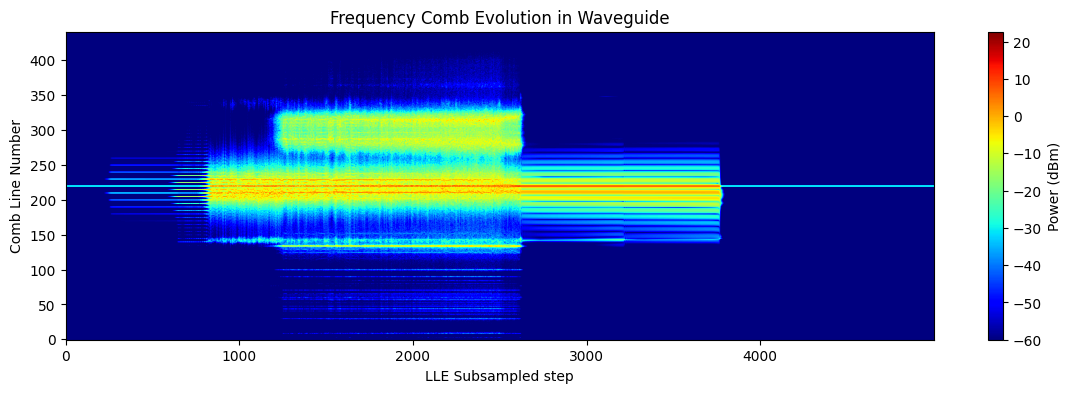

In [42]:
Ewg_dbm = 10 * np.log10(np.abs(Ewg)**2) + 30
E_wg_dbm = np.where(Ewg_dbm < -60, -60, Ewg_dbm)
plt.figure(figsize=(14,4))
plt.imshow(E_wg_dbm.T, aspect='auto', cmap='jet', origin='lower')
plt.colorbar(label='Power (dBm)')
plt.xlabel('LLE Subsampled step')
plt.ylabel('Comb Line Number')
plt.title('Frequency Comb Evolution in Waveguide')
plt.show()

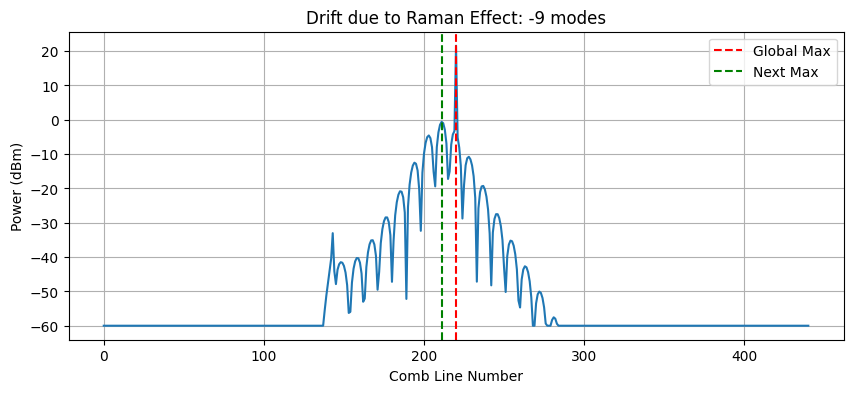

In [56]:
# plot the drift of due to raman vs LLE steps using E_wg_dbm
plt.figure(figsize=(10,4))
a = E_wg_dbm[3500]
plt.plot(a)
# calculate the difference between global max and the next max to find the drift
max_idx = np.argmax(a)
a_copy = a.copy()
a_copy[max_idx] = -100
next_max_idx = np.argmax(a_copy)
drift = next_max_idx - max_idx
plt.axvline(x=max_idx, color='r', linestyle='--', label='Global Max')
plt.axvline(x=next_max_idx, color='g', linestyle='--', label='Next Max')
plt.title(f'Drift due to Raman Effect: {drift} modes')
plt.xlabel('Comb Line Number')
plt.ylabel('Power (dBm)')
plt.legend()
plt.grid()
plt.show()

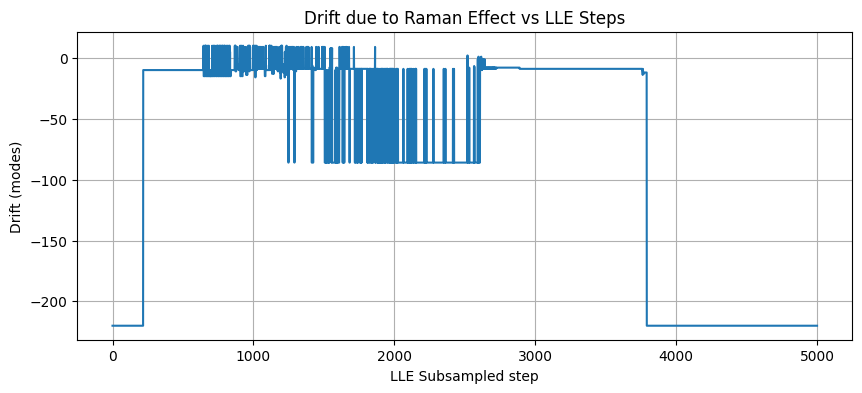

In [53]:
# plot the shift for each LLE step
drift_list = []
for i in range(E_wg_dbm.shape[0]):
    a = E_wg_dbm[i]
    max_idx = np.argmax(a)
    a_copy = a.copy()
    a_copy[max_idx] = -100
    next_max_idx = np.argmax(a_copy)
    drift = next_max_idx - max_idx
    drift_list.append(drift)
plt.figure(figsize=(10,4))
plt.plot(drift_list)
plt.title('Drift due to Raman Effect vs LLE Steps')
plt.xlabel('LLE Subsampled step')
plt.ylabel('Drift (modes)')
plt.grid()
plt.show()

In [ ]:
dks_init = dict()
idx=0
dks_init['DKS_init'] = u_probe[idx]
dks_init['detuning'] = detuning[idx]
dks_init['detuning_end'] = detuning[-1]
savemat('My_DKS_init_a3c.mat', dks_init)

In [ ]:
plt.plot(detuning_gHz,Pcomb*1e3)

In [ ]:
desired_spec = dict()
idx = 4759
desired_spec['Awg'] = Awg[idx]
desired_spec['Ewg'] = Ewg[idx]
desired_spec['detuning'] = detuning[idx]
savemat('desired_spec_multi_pmp.mat', desired_spec)

In [ ]:
plt.figure(figsize=(14,3))
plt.imshow(np.abs(Acav).T, aspect='auto', cmap='jet', origin='lower')
plt.xlabel('LLE Subsampled step', fontsize=14)
plt.ylabel(r"$t_R$ (ps)", fontsize=14)
plt.colorbar()
plt.show()
# %%

In [ ]:
plt.figure(figsize=(10,3))
plt.imshow(np.abs(Ecav).T, aspect='auto', cmap='jet')#, extent=[detuning_gHz[0], detuning_gHz[-1],modes[0], modes[-1]]
plt.colorbar()
plt.xlabel('Detuning (GHz)', fontsize=14)
plt.ylabel(r"$\mu$", fontsize=14)
plt.show()
# %%

In [ ]:
plt.figure(figsize=(10,3))
# plt.plot(Pcomb*1e3)
plt.plot(detuning*1e-9/(2*np.pi), np.flip(Pcomb)*1e3)
plt.xlabel('Detuning (GHz)')
plt.ylabel('Power (mW)')
plt.grid()
plt.show()
# %%

In [ ]:
# dic = {'Pcomb': Pcomb*1e3}
# savemat('Pcomb.mat', dic)
Pcomb_old = loadmat('Pcomb.mat')['Pcomb'][0]
plt.figure(figsize=(10,3))
plt.plot(Pcomb_old/np.max(Pcomb_old), label='Old')
plt.plot(Pcomb/np.max(Pcomb), label='New')
plt.show()

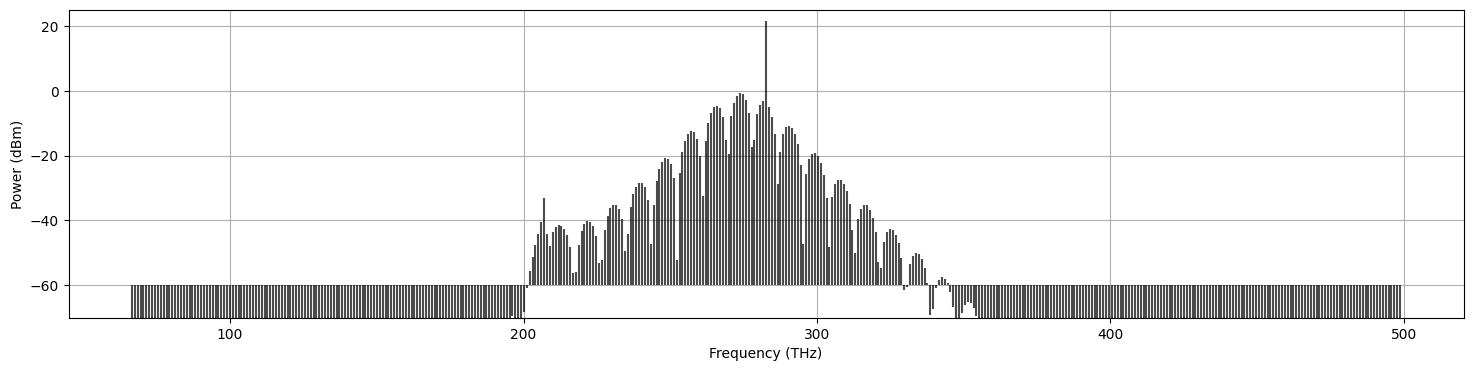

In [48]:
def plot_comb_power(idx, xaxis='freq'):
    plt.figure(figsize=(18,4))
    if xaxis == 'modes':
        x = np.arange(-(len(Ewg[idx])-1)//2, len(Ecav[idx])//2 +1, 1)
        plt.xlabel('Comb Line Number')
    elif xaxis == 'freq':
        x = fpmp[0].cpu().numpy() + np.arange(-(len(Ewg[idx])-1)//2, len(Ewg[idx])//2 +1, 1)*FSR.cpu().numpy()
        x = x*1e-12
        plt.xlabel('Frequency (THz)')
    x_ = np.zeros(x.size*3)
    x_[::3] = x
    x_[1::3] = x
    x_[2::3] = x
    x = x_

    y = 10*np.log10(np.abs(Ewg[idx])**2)+30
    y_ = np.zeros(y.size * 3)
    floor = -60
    y_[::3] = floor
    y_[1::3] = y
    y_[2::3] = floor
    y = y_

    
    # plt.scatter(x, y, color='k')
    # for xx,yy in zip(x, y):
    plt.vlines(x[::3], ymin=-60, ymax=y[1::3], colors='k', linestyles='-', alpha=0.7)
    plt.ylim(floor-10,25)
    
    plt.ylabel('Power (dBm)')
    plt.grid()
    plt.show()

# %%
plot_comb_power(3500)

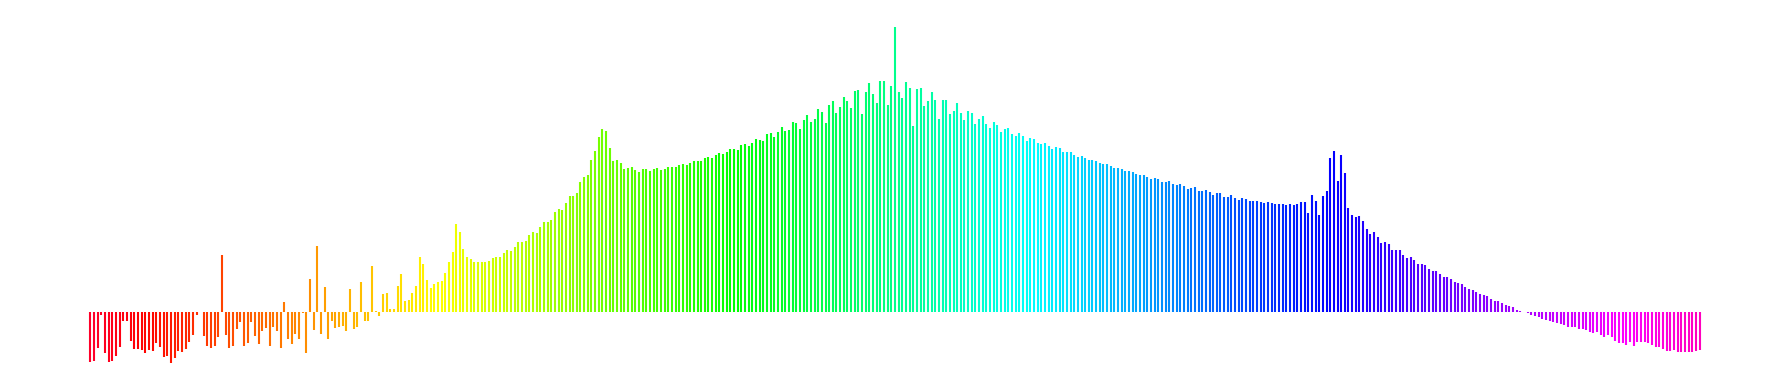

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_comb_power(idx, xaxis='freq'):
    if xaxis == 'modes':
        x = np.arange(-(len(Ewg[idx])-1)//2, len(Ewg[idx])//2 + 1, 1)
        plt.xlabel('Comb Line Number')
    elif xaxis == 'freq':
        x = fpmp[0].cpu().numpy() + np.arange(-(len(Ewg[idx])-1)//2, len(Ewg[idx])//2 + 1, 1) * FSR.cpu().numpy()
        x = x * 1e-12
    
    # Preparing x for vertical line plotting
    x_ = np.zeros(x.size * 3)
    x_[::3] = x
    x_[1::3] = x
    x_[2::3] = x
    x = x_

    # Power calculation in dBm
    y = 10 * np.log10(np.abs(Ewg[idx])**2) + 30
    y_ = np.zeros(y.size * 3)
    floor = -100  # Minimum power level
    y_[::3] = floor
    y_[1::3] = y
    y_[2::3] = floor
    y = y_

    # Create the plot
    plt.figure(figsize=(18, 4))
    # set dark background
    plt.style.use('seaborn-v0_8-white')

    # Use a colormap to assign colors
    colors = cm.gist_rainbow(np.linspace(0, 1, len(Ewg[idx])))  # Jet colormap
    # flip the colors
    # colors = colors[::-1]

    # Plot each comb line with its respective color
    for i in range(len(Ewg[idx])):
        plt.vlines(x[3*i], ymin=floor, ymax=y[3*i+1], colors=colors[i], linestyles='-', alpha=1)

    # Hide the y-axis
    ax = plt.gca()  # Get current axes
    ax.yaxis.set_visible(False)  # Hide the y-axis
    ax.xaxis.set_visible(False)  # Hide the y-axis
    ax.spines['left'].set_visible(False)  # Hide the left spine
    ax.spines['right'].set_visible(False)  # Hide the left spine
    ax.spines['top'].set_visible(False)  # Hide the left spine
    ax.spines['bottom'].set_visible(False)  # Hide the left spine
    ax.tick_params(axis='y', which='both', left=False)  # Hide y-axis ticks
    
    # Plot settings
    # plt.grid(axis='x')  # Keep only the grid for x-axis
    plt.tight_layout()
    plt.savefig('./results/comb_power_obtained.svg', format='svg')
    plt.show()
    plt.style.use('default')

# %%
plot_comb_power(2600)


In [ ]:
def plot_soliton_time(idx):
    tr = tR.cpu().numpy()
    t = np.linspace(-tr/2,tr/2, len(Ecav[idx]))*1e12

    plt.figure(figsize=(14,4))
    plt.plot(t, np.abs(Acav[idx])**2)
    plt.xlabel('Time (ps)')
    plt.ylabel('Power (W)')
    plt.grid()
    plt.show()
# %%
plot_soliton_time(4000)

In [ ]:
# plot the autocorr of np.abs(Acav[idx])**2
def plot_autocorr(idx):
    tr = tR.cpu().numpy()
    autocorr = np.correlate(np.abs(Acav[idx])**2, np.abs(Acav[idx])**2, mode='full')
    t = np.linspace(-tr/2, tr/2, len(autocorr))*1e12
    plt.figure(figsize=(14,4))
    plt.plot(t, autocorr)
    plt.xlabel('Time (ps)')
    plt.ylabel('Autocorrelation')
    plt.grid()
    plt.show()

plot_autocorr(1000)

In [ ]:
# function to plot the spectrum of autocorrelation 
def plot_autocorr_spectrum(idx):
    tr = tR.cpu().numpy()
    autocorr = np.correlate(np.abs(Acav[idx])**2, np.abs(Acav[idx])**2, mode='full')
    t = np.linspace(-tr/2, tr/2, len(autocorr))
    freq = np.fft.fftshift(np.fft.fftfreq(len(autocorr), d=t[1]-t[0]))*1e-12
    autocorr_fft = np.fft.fftshift(np.fft.fft(autocorr))
    plt.figure(figsize=(14,4))
    plt.plot(freq, np.abs(autocorr_fft))
    plt.xlabel('Frequency (THz)')
    plt.ylabel('Power')
    plt.grid()
    plt.show()

plot_autocorr_spectrum(4200)